In [3]:
import os
import json
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# ── Premium chart settings ──────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "font.family"       : "sans-serif",
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--"
})

# Brand colors
PURPLE  = "#534AB7"
TEAL    = "#1D9E75"
CORAL   = "#D85A30"
AMBER   = "#BA7517"
GRAY    = "#888780"
RED     = "#E24B4A"
GREEN   = "#639922"
BLUE    = "#378ADD"

# Paths
DATA_PATH    = "/Users/ashishjain/Documents/assignment/transcript-intelligence/data/processed/all_calls.csv"
CHARTS_PATH  = "/Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/"
EXPORTS_PATH = "/Users/ashishjain/Documents/assignment/transcript-intelligence/data/exports/"

print("✅ Setup complete")

✅ Setup complete


In [4]:
df = pd.read_csv(DATA_PATH)

df["topics"]       = df["topics"].apply(ast.literal_eval)
df["action_items"] = df["action_items"].apply(ast.literal_eval)
df["speakers"]     = df["speakers"].apply(ast.literal_eval)
df["key_moments"]  = df["key_moments"].apply(ast.literal_eval)
df["start_time"]   = pd.to_datetime(df["start_time"])
df["week"]         = df["start_time"].dt.to_period("W")

print(f"✅ Loaded : {len(df)} calls")
print(f"🏷️  Themes : {df['theme'].nunique()}")
print(f"📅 Dates  : {df['start_time'].min().date()} → {df['start_time'].max().date()}")

✅ Loaded : 100 calls
🏷️  Themes : 10
📅 Dates  : 2026-02-03 → 2026-04-28


/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/2737377220.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"]         = df["start_time"].dt.to_period("W")


/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/286628394.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


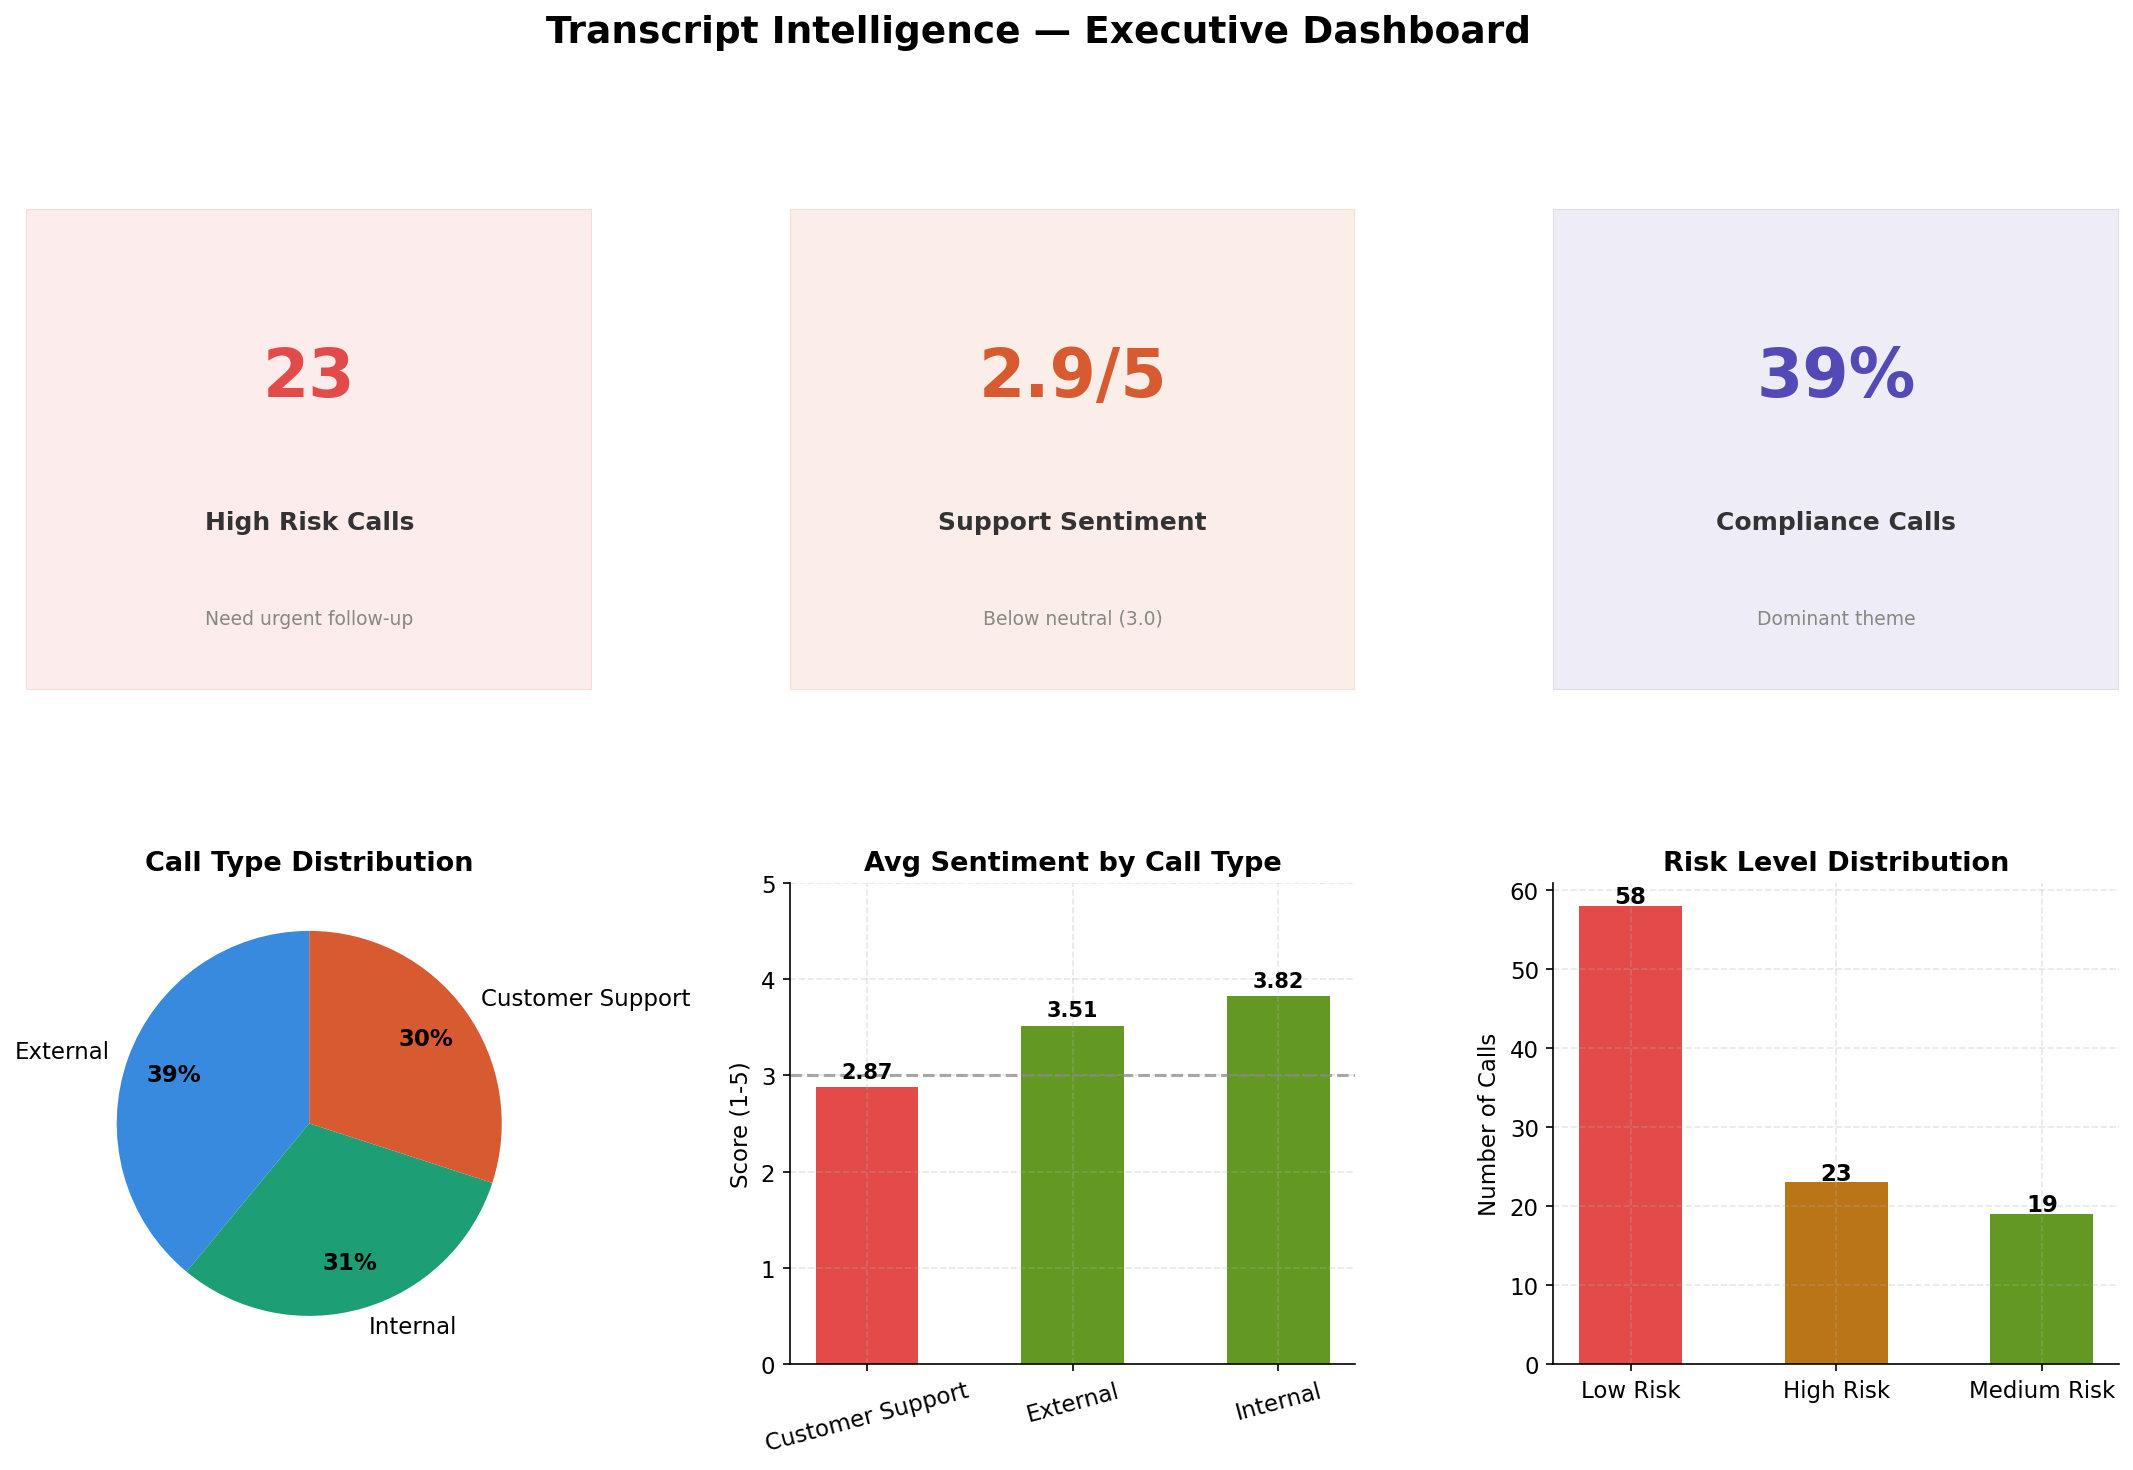

✅ Saved → 01_executive_dashboard.png


In [5]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Transcript Intelligence — Executive Dashboard",
             fontsize=18, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── KPI Cards (top row) ──────────────────────────
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi3 = fig.add_subplot(gs[0, 2])

def kpi_card(ax, value, label, sublabel, color):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1,
                  fill=True, color=color, alpha=0.1,
                  transform=ax.transAxes))
    ax.text(0.5, 0.65, str(value), ha="center",
            va="center", fontsize=32, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.35, label, ha="center",
            va="center", fontsize=12, fontweight="bold",
            color="#333", transform=ax.transAxes)
    ax.text(0.5, 0.15, sublabel, ha="center",
            va="center", fontsize=9,
            color=GRAY, transform=ax.transAxes)

high_risk = len(df[df["risk_level"] == "🔴 High Risk"])
support_score = df[df["call_type"]=="Customer Support"]["sentiment_score"].mean()
compliance_pct = len(df[df["theme"]=="Compliance and Security"])/len(df)*100

kpi_card(ax_kpi1, f"{high_risk}",
         "High Risk Calls",
         "Need urgent follow-up", RED)
kpi_card(ax_kpi2, f"{support_score:.1f}/5",
         "Support Sentiment",
         "Below neutral (3.0)", CORAL)
kpi_card(ax_kpi3, f"{compliance_pct:.0f}%",
         "Compliance Calls",
         "Dominant theme", PURPLE)

# ── Bottom row charts ────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])
ax3 = fig.add_subplot(gs[1, 2])

# Chart A — Call type distribution
ct_counts = df["call_type"].value_counts()
colors_ct = [BLUE, TEAL, CORAL]
wedges, texts, autotexts = ax1.pie(
    ct_counts.values,
    labels=ct_counts.index,
    colors=colors_ct,
    autopct="%1.0f%%",
    startangle=90,
    pctdistance=0.75
)
for text in autotexts:
    text.set_fontweight("bold")
ax1.set_title("Call Type Distribution")

# Chart B — Avg sentiment by call type
ct_sentiment = df.groupby("call_type")["sentiment_score"] \
                 .mean().sort_values()
bar_colors   = [RED if v < 3.0 else
                AMBER if v < 3.5 else
                GREEN for v in ct_sentiment.values]
bars = ax2.bar(ct_sentiment.index, ct_sentiment.values,
               color=bar_colors, width=0.5)
ax2.axhline(3.0, color=GRAY, linestyle="--",
            linewidth=1.5, alpha=0.7)
ax2.set_ylim(0, 5)
ax2.set_title("Avg Sentiment by Call Type")
ax2.set_ylabel("Score (1-5)")
ax2.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, ct_sentiment.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             f"{val:.2f}", ha="center",
             fontweight="bold", fontsize=10)

# Chart C — Risk distribution
risk_counts  = df["risk_level"].value_counts()
risk_labels  = [r.split(" ", 1)[1] for r in risk_counts.index]
risk_colors  = [RED, AMBER, GREEN]
ax3.bar(risk_labels, risk_counts.values,
        color=risk_colors, width=0.5)
ax3.set_title("Risk Level Distribution")
ax3.set_ylabel("Number of Calls")
for i, v in enumerate(risk_counts.values):
    ax3.text(i, v + 0.3, str(v),
             ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}01_executive_dashboard.png",
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → 01_executive_dashboard.png")

/Users/ashishjain/Documents/assignment/transcript-intelligence/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/ashishjain/Documents/assignment/transcript-intelligence/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/ashishjain/Documents/assignment/transcript-intelligence/.venv/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/2223971128.py:43: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CHARTS_PATH}02_theme_intelligence.png",
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/2223971128.py:43: UserWarning: Glyph 1289

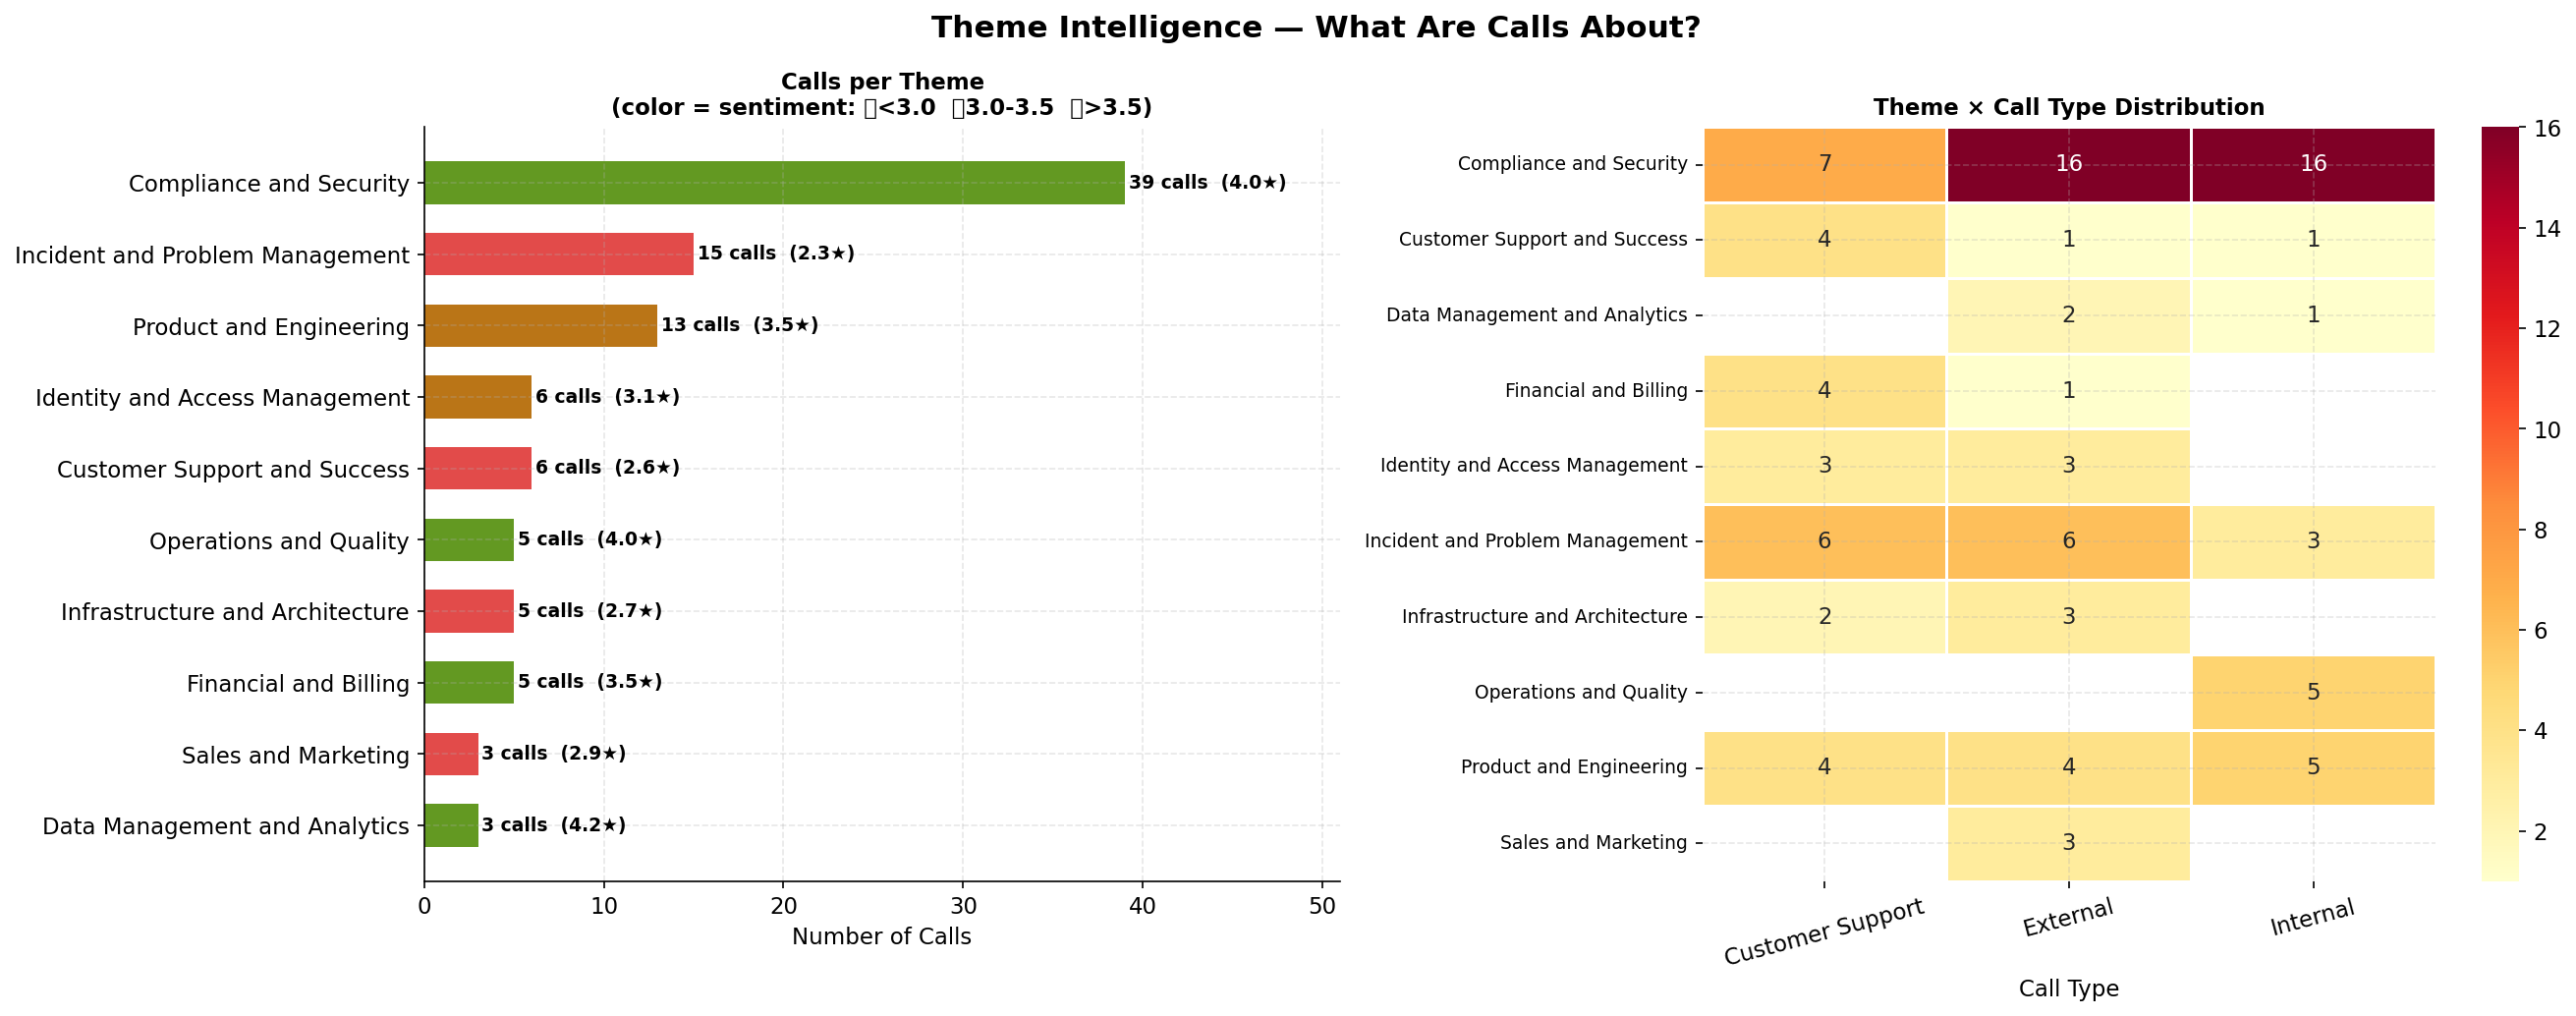

✅ Saved → 02_theme_intelligence.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Theme Intelligence — What Are Calls About?",
             fontsize=15, fontweight="bold")

# Chart A — Theme distribution with sentiment color
theme_stats = df.groupby("theme").agg(
    count         = ("theme", "count"),
    avg_sentiment = ("sentiment_score", "mean")
).reset_index().sort_values("count", ascending=True)

bar_colors = [RED    if s < 3.0 else
              AMBER  if s < 3.5 else
              GREEN  for s in theme_stats["avg_sentiment"]]

bars = axes[0].barh(theme_stats["theme"],
                    theme_stats["count"],
                    color=bar_colors, height=0.6)
axes[0].set_title("Calls per Theme\n(color = sentiment: 🔴<3.0  🟡3.0-3.5  🟢>3.5)",
                   fontsize=11)
axes[0].set_xlabel("Number of Calls")
for bar, row in zip(bars, theme_stats.itertuples()):
    axes[0].text(bar.get_width() + 0.2,
                 bar.get_y() + bar.get_height()/2,
                 f"{row.count} calls  ({row.avg_sentiment:.1f}★)",
                 va="center", fontsize=9, fontweight="bold")
axes[0].set_xlim(0, theme_stats["count"].max() + 12)

# Chart B — Theme × Call Type heatmap
theme_type = pd.crosstab(df["theme"], df["call_type"])
mask = theme_type == 0
sns.heatmap(theme_type, annot=True, fmt="d",
            cmap="YlOrRd", ax=axes[1],
            linewidths=0.5, linecolor="white",
            mask=mask, annot_kws={"size": 11})
axes[1].set_title("Theme × Call Type Distribution",
                   fontsize=11)
axes[1].set_xlabel("Call Type")
axes[1].set_ylabel("")
plt.setp(axes[1].get_xticklabels(), rotation=15)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}02_theme_intelligence.png",
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → 02_theme_intelligence.png")

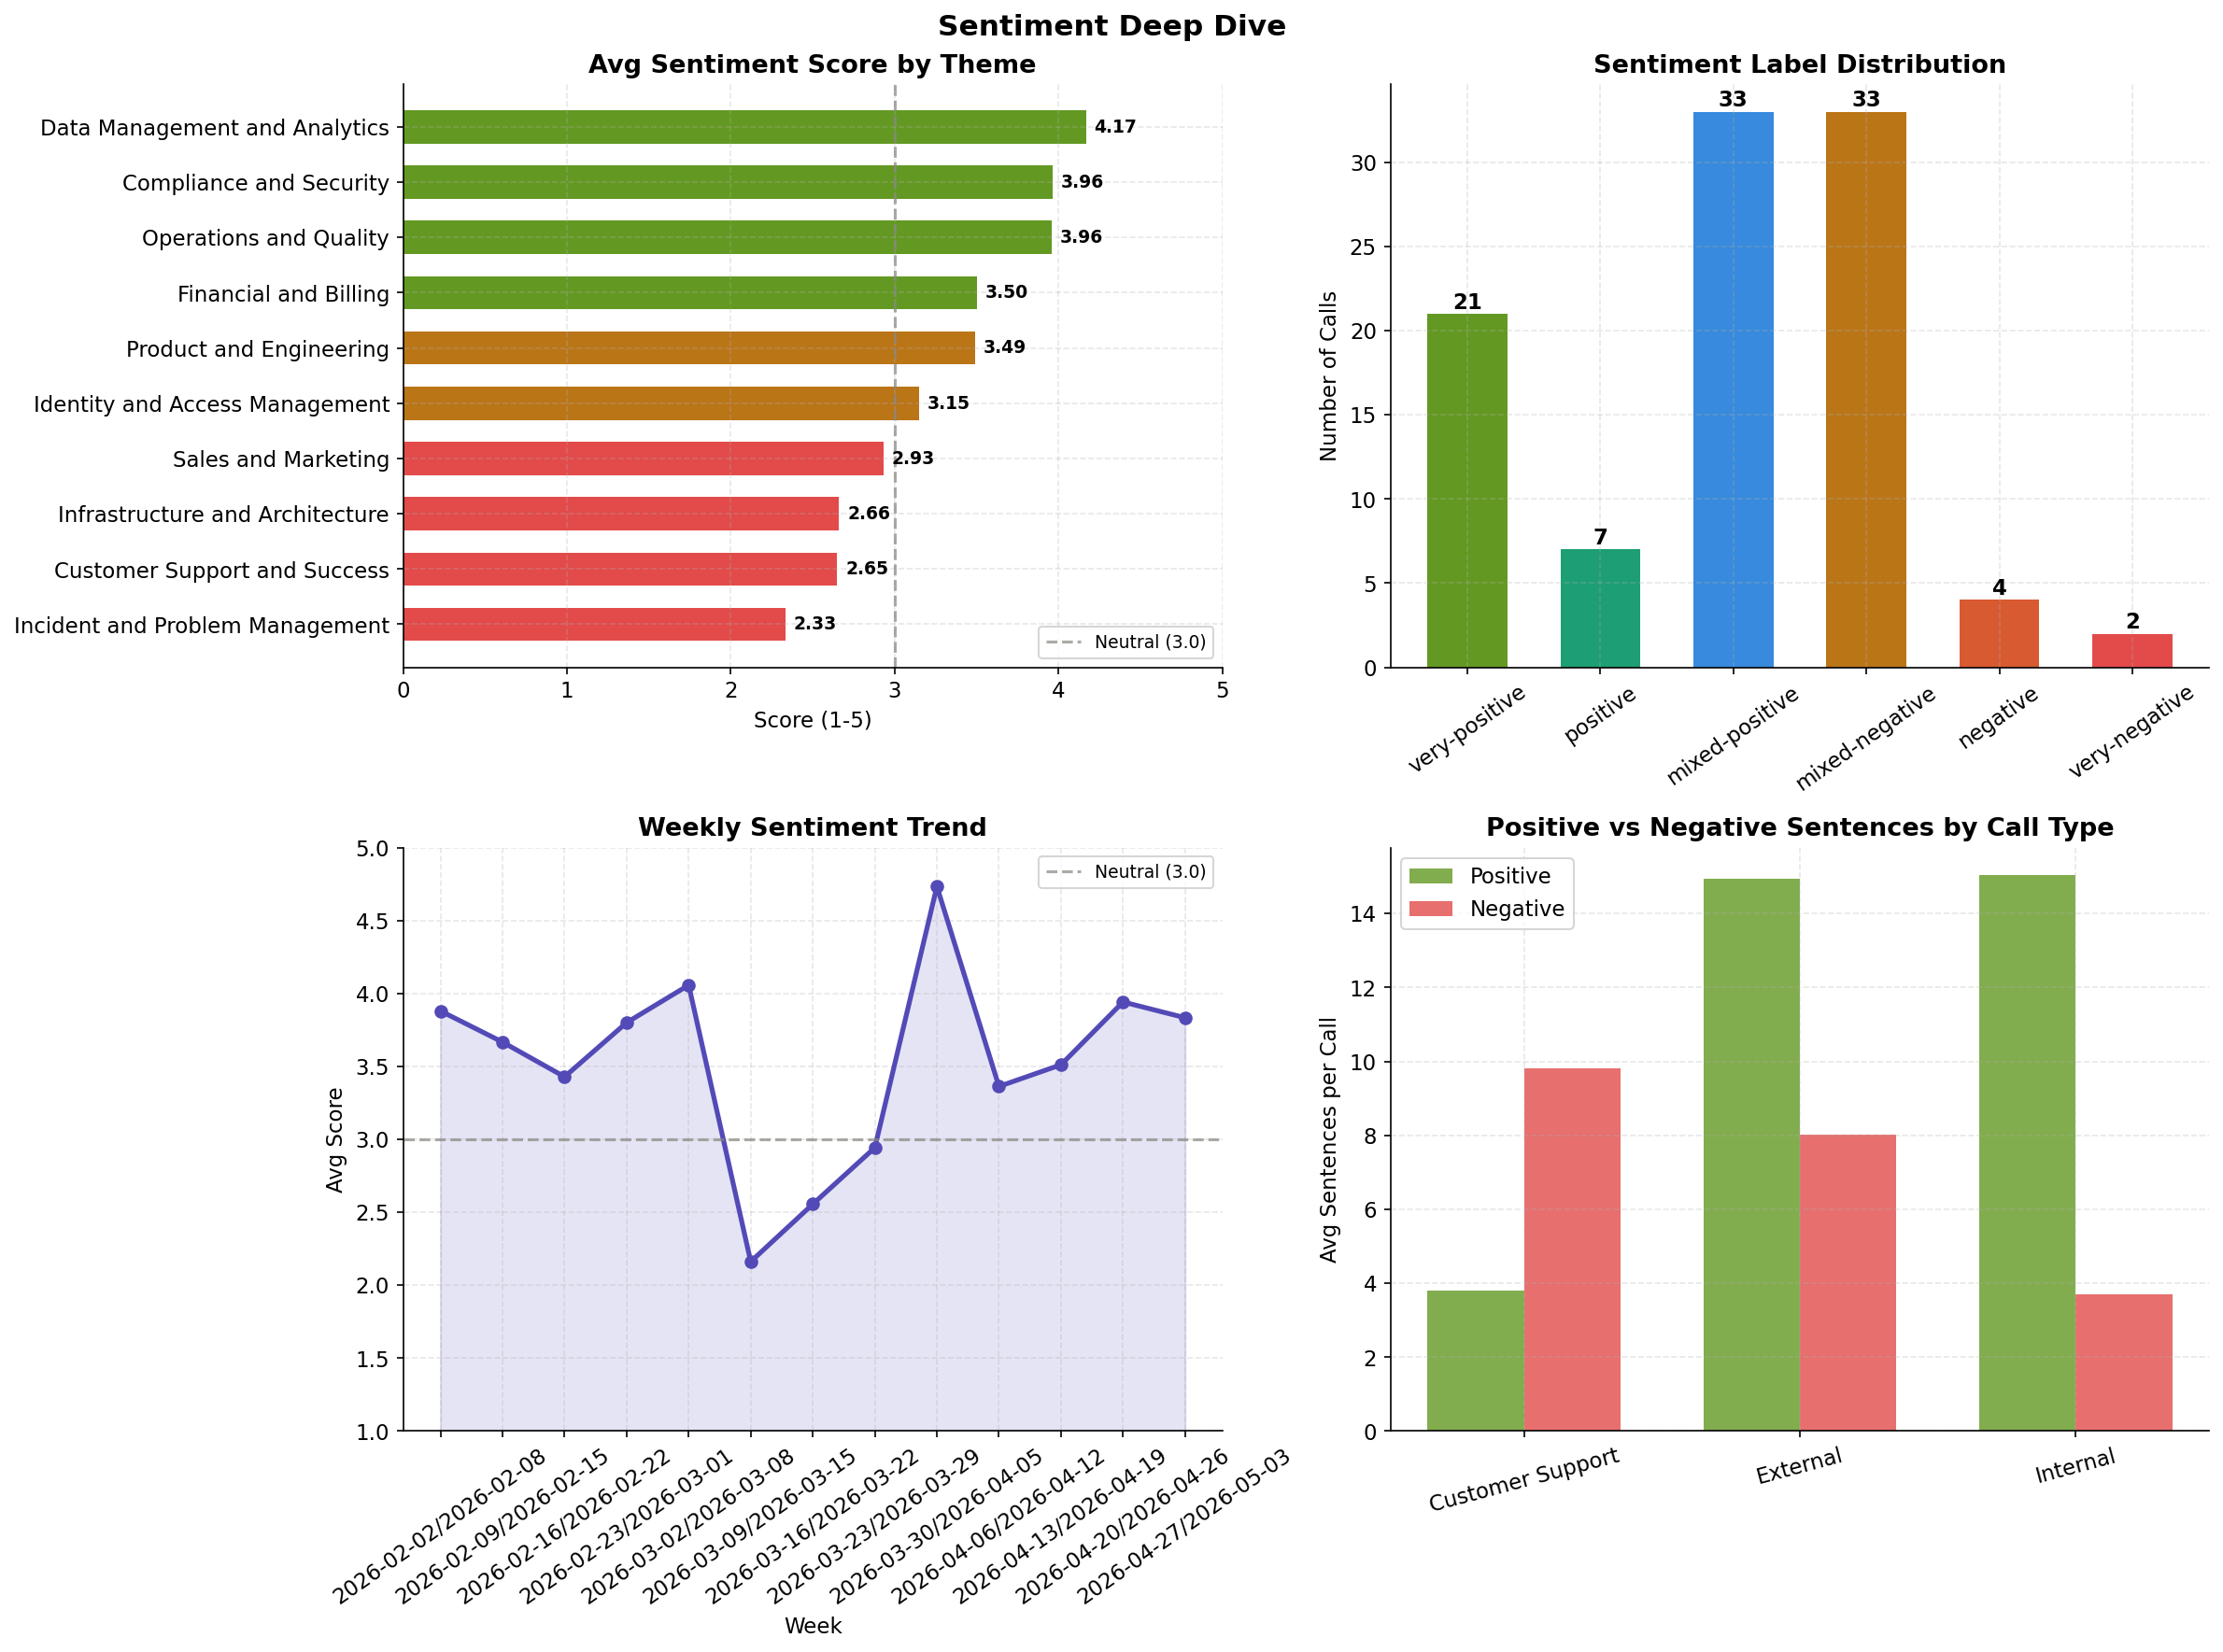

✅ Saved → 03_sentiment_deepdive.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Sentiment Deep Dive", fontsize=15, fontweight="bold")

# Chart A — Sentiment score by theme (horizontal)
theme_sent = df.groupby("theme")["sentiment_score"] \
               .mean().sort_values()
colors_ts  = [RED   if v < 3.0 else
              AMBER if v < 3.5 else
              GREEN for v in theme_sent.values]
bars = axes[0,0].barh(theme_sent.index, theme_sent.values,
                       color=colors_ts, height=0.6)
axes[0,0].axvline(3.0, color=GRAY, linestyle="--",
                   linewidth=1.5, alpha=0.7,
                   label="Neutral (3.0)")
axes[0,0].set_xlim(0, 5)
axes[0,0].set_title("Avg Sentiment Score by Theme")
axes[0,0].set_xlabel("Score (1-5)")
axes[0,0].legend(fontsize=9)
for bar, val in zip(bars, theme_sent.values):
    axes[0,0].text(val + 0.05,
                   bar.get_y() + bar.get_height()/2,
                   f"{val:.2f}", va="center",
                   fontsize=9, fontweight="bold")

# Chart B — Sentiment label distribution
sentiment_order = ["very-positive", "positive",
                   "mixed-positive", "mixed-negative",
                   "negative", "very-negative"]
sent_colors     = [GREEN, TEAL, BLUE, AMBER, CORAL, RED]
sent_counts = df["sentiment"].value_counts() \
                .reindex(sentiment_order).fillna(0)
bars2 = axes[0,1].bar(sentiment_order, sent_counts.values,
                       color=sent_colors, width=0.6)
axes[0,1].set_title("Sentiment Label Distribution")
axes[0,1].set_ylabel("Number of Calls")
axes[0,1].tick_params(axis="x", rotation=35)
for bar, val in zip(bars2, sent_counts.values):
    if val > 0:
        axes[0,1].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 0.3,
                       str(int(val)), ha="center",
                       fontweight="bold")

# Chart C — Sentiment trend over time
weekly = df.groupby("week")["sentiment_score"] \
           .mean().reset_index()
weekly["week_str"] = weekly["week"].astype(str)
axes[1,0].plot(weekly["week_str"], weekly["sentiment_score"],
               marker="o", linewidth=2.5,
               color=PURPLE, markersize=6)
axes[1,0].fill_between(weekly["week_str"],
                        weekly["sentiment_score"],
                        alpha=0.15, color=PURPLE)
axes[1,0].axhline(3.0, color=GRAY, linestyle="--",
                   linewidth=1.5, alpha=0.7,
                   label="Neutral (3.0)")
axes[1,0].set_title("Weekly Sentiment Trend")
axes[1,0].set_xlabel("Week")
axes[1,0].set_ylabel("Avg Score")
axes[1,0].set_ylim(1, 5)
axes[1,0].tick_params(axis="x", rotation=35)
axes[1,0].legend(fontsize=9)

# Chart D — Positive vs Negative sentences
sent_breakdown = df.groupby("call_type")[
    ["positive_sents", "negative_sents"]
].mean()
x = np.arange(len(sent_breakdown))
w = 0.35
axes[1,1].bar(x - w/2, sent_breakdown["positive_sents"],
               w, label="Positive", color=GREEN, alpha=0.8)
axes[1,1].bar(x + w/2, sent_breakdown["negative_sents"],
               w, label="Negative", color=RED, alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(sent_breakdown.index, rotation=15)
axes[1,1].set_title("Positive vs Negative Sentences by Call Type")
axes[1,1].set_ylabel("Avg Sentences per Call")
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}03_sentiment_deepdive.png",
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → 03_sentiment_deepdive.png")

/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/1761285952.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/1761285952.py:52: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/1761285952.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/1761285952.py:53: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CHARTS_PATH}04_bonus_insights.png",
/var/folders/dr/mh095vrx47v864kyvzp102g00000gn/T/ipykernel_15957/1761285952.py:53: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{CHARTS_PATH}04_bonus_insights

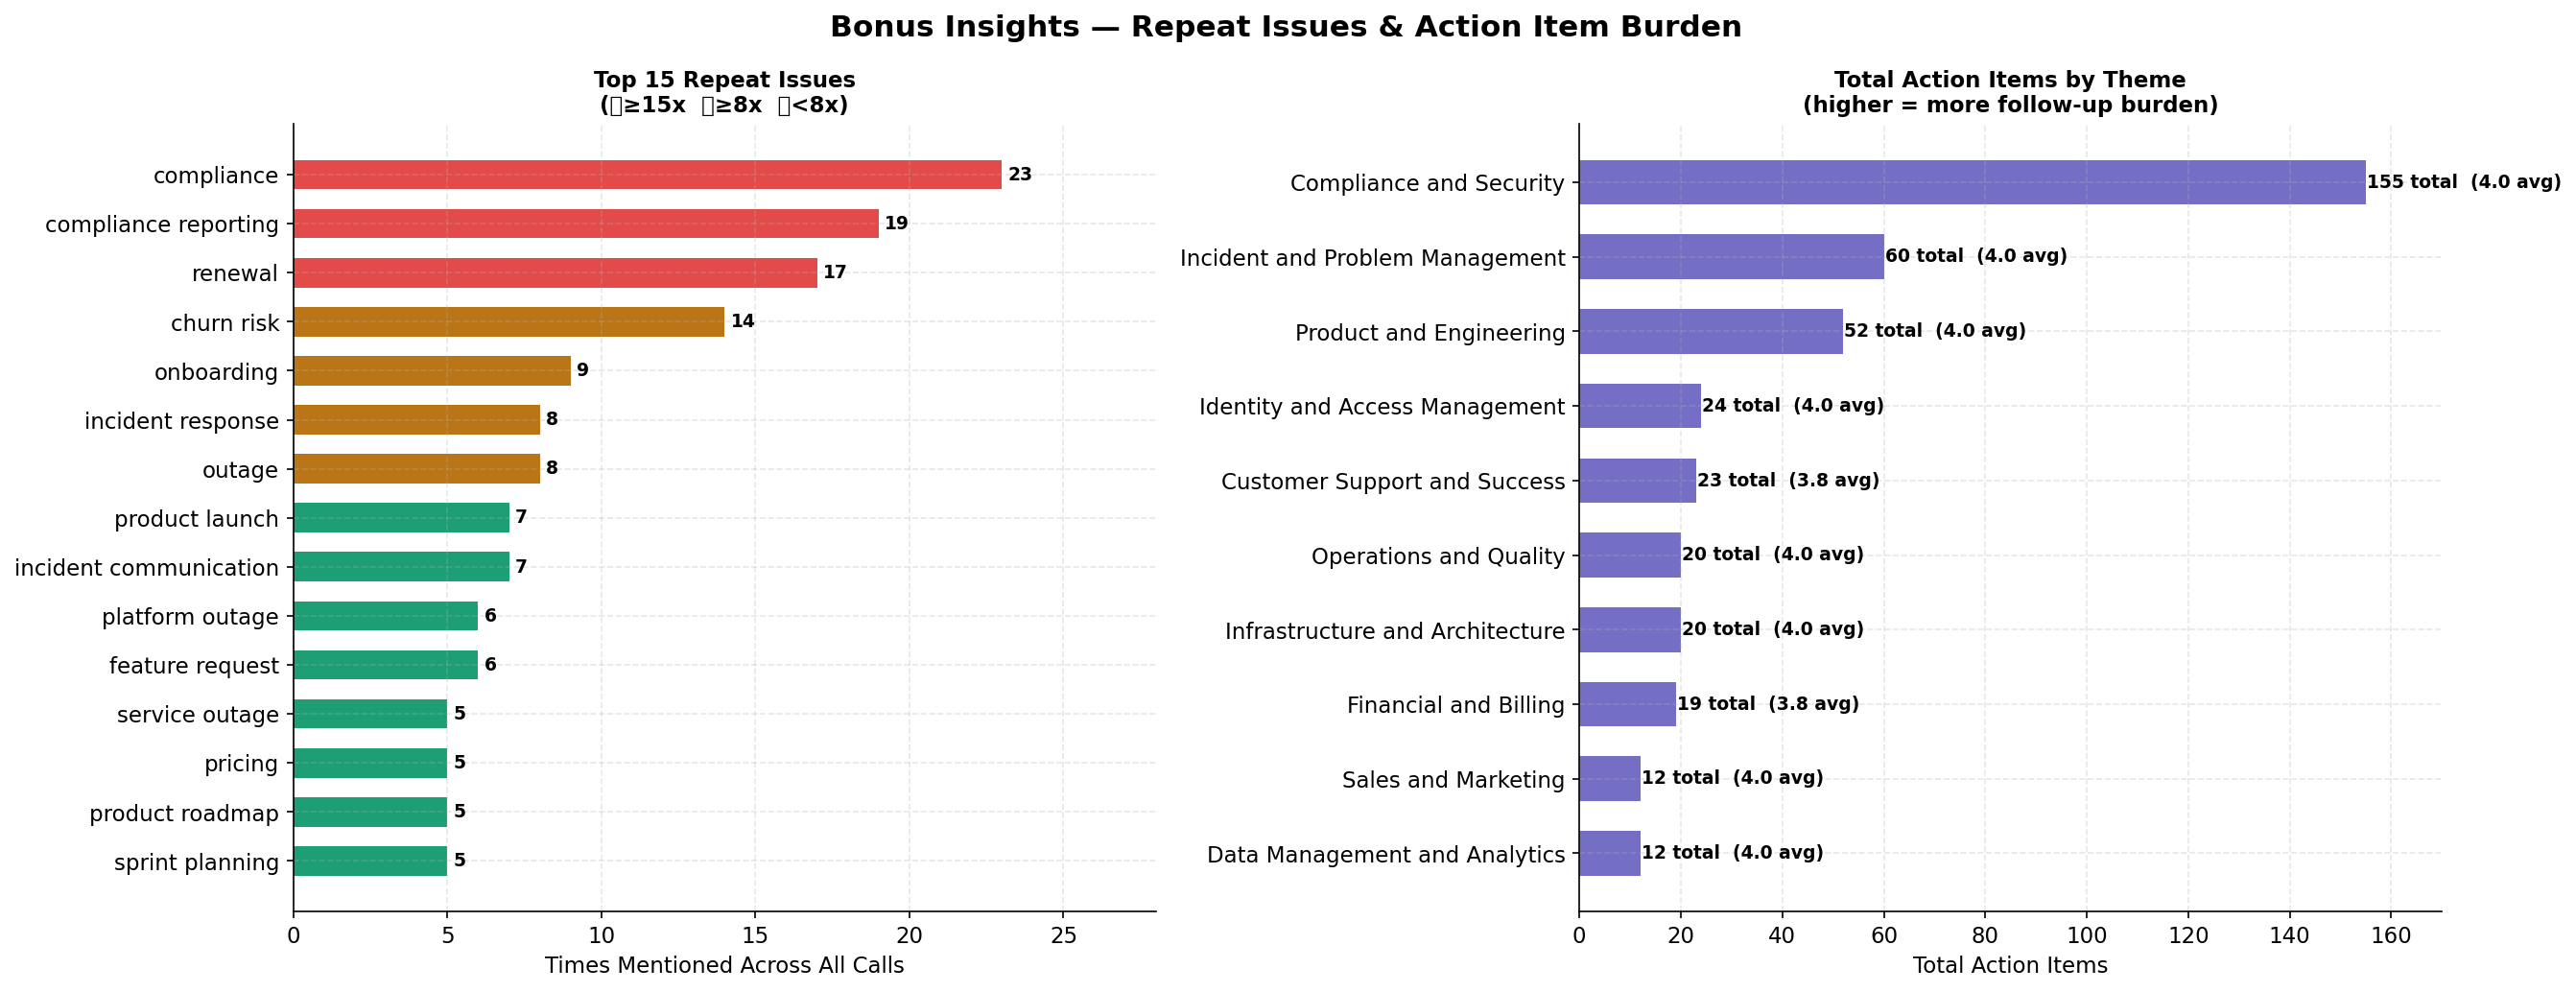

✅ Saved → 04_bonus_insights.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Bonus Insights — Repeat Issues & Action Item Burden",
             fontsize=15, fontweight="bold")

# Chart A — Top 15 repeat issues
from collections import Counter
all_topics   = [t for topics in df["topics"] for t in topics]
topic_counts = Counter(all_topics)
top15_topics = pd.DataFrame(
    topic_counts.most_common(15),
    columns=["topic", "count"]
)

colors_topics = [RED   if c >= 15 else
                 AMBER if c >= 8  else
                 TEAL  for c in top15_topics["count"]]

axes[0].barh(top15_topics["topic"][::-1],
             top15_topics["count"][::-1],
             color=colors_topics[::-1], height=0.6)
axes[0].set_title("Top 15 Repeat Issues\n"
                   "(🔴≥15x  🟡≥8x  🟢<8x)",
                   fontsize=11)
axes[0].set_xlabel("Times Mentioned Across All Calls")
for i, (_, row) in enumerate(
        top15_topics[::-1].reset_index().iterrows()):
    axes[0].text(row["count"] + 0.2, i,
                 str(row["count"]),
                 va="center", fontweight="bold", fontsize=9)
axes[0].set_xlim(0, top15_topics["count"].max() + 5)

# Chart B — Action items by theme
theme_actions = df.groupby("theme")["num_action_items"] \
                  .agg(["mean", "sum"]) \
                  .reset_index() \
                  .sort_values("sum", ascending=True)

bars = axes[1].barh(theme_actions["theme"],
                    theme_actions["sum"],
                    color=PURPLE, alpha=0.8, height=0.6)
axes[1].set_title("Total Action Items by Theme\n"
                   "(higher = more follow-up burden)",
                   fontsize=11)
axes[1].set_xlabel("Total Action Items")
for bar, row in zip(bars, theme_actions.itertuples()):
    axes[1].text(bar.get_width() + 0.2,
                 bar.get_y() + bar.get_height()/2,
                 f"{row.sum} total  ({row.mean:.1f} avg)",
                 va="center", fontsize=9, fontweight="bold")
axes[1].set_xlim(0, theme_actions["sum"].max() + 15)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}04_bonus_insights.png",
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → 04_bonus_insights.png")

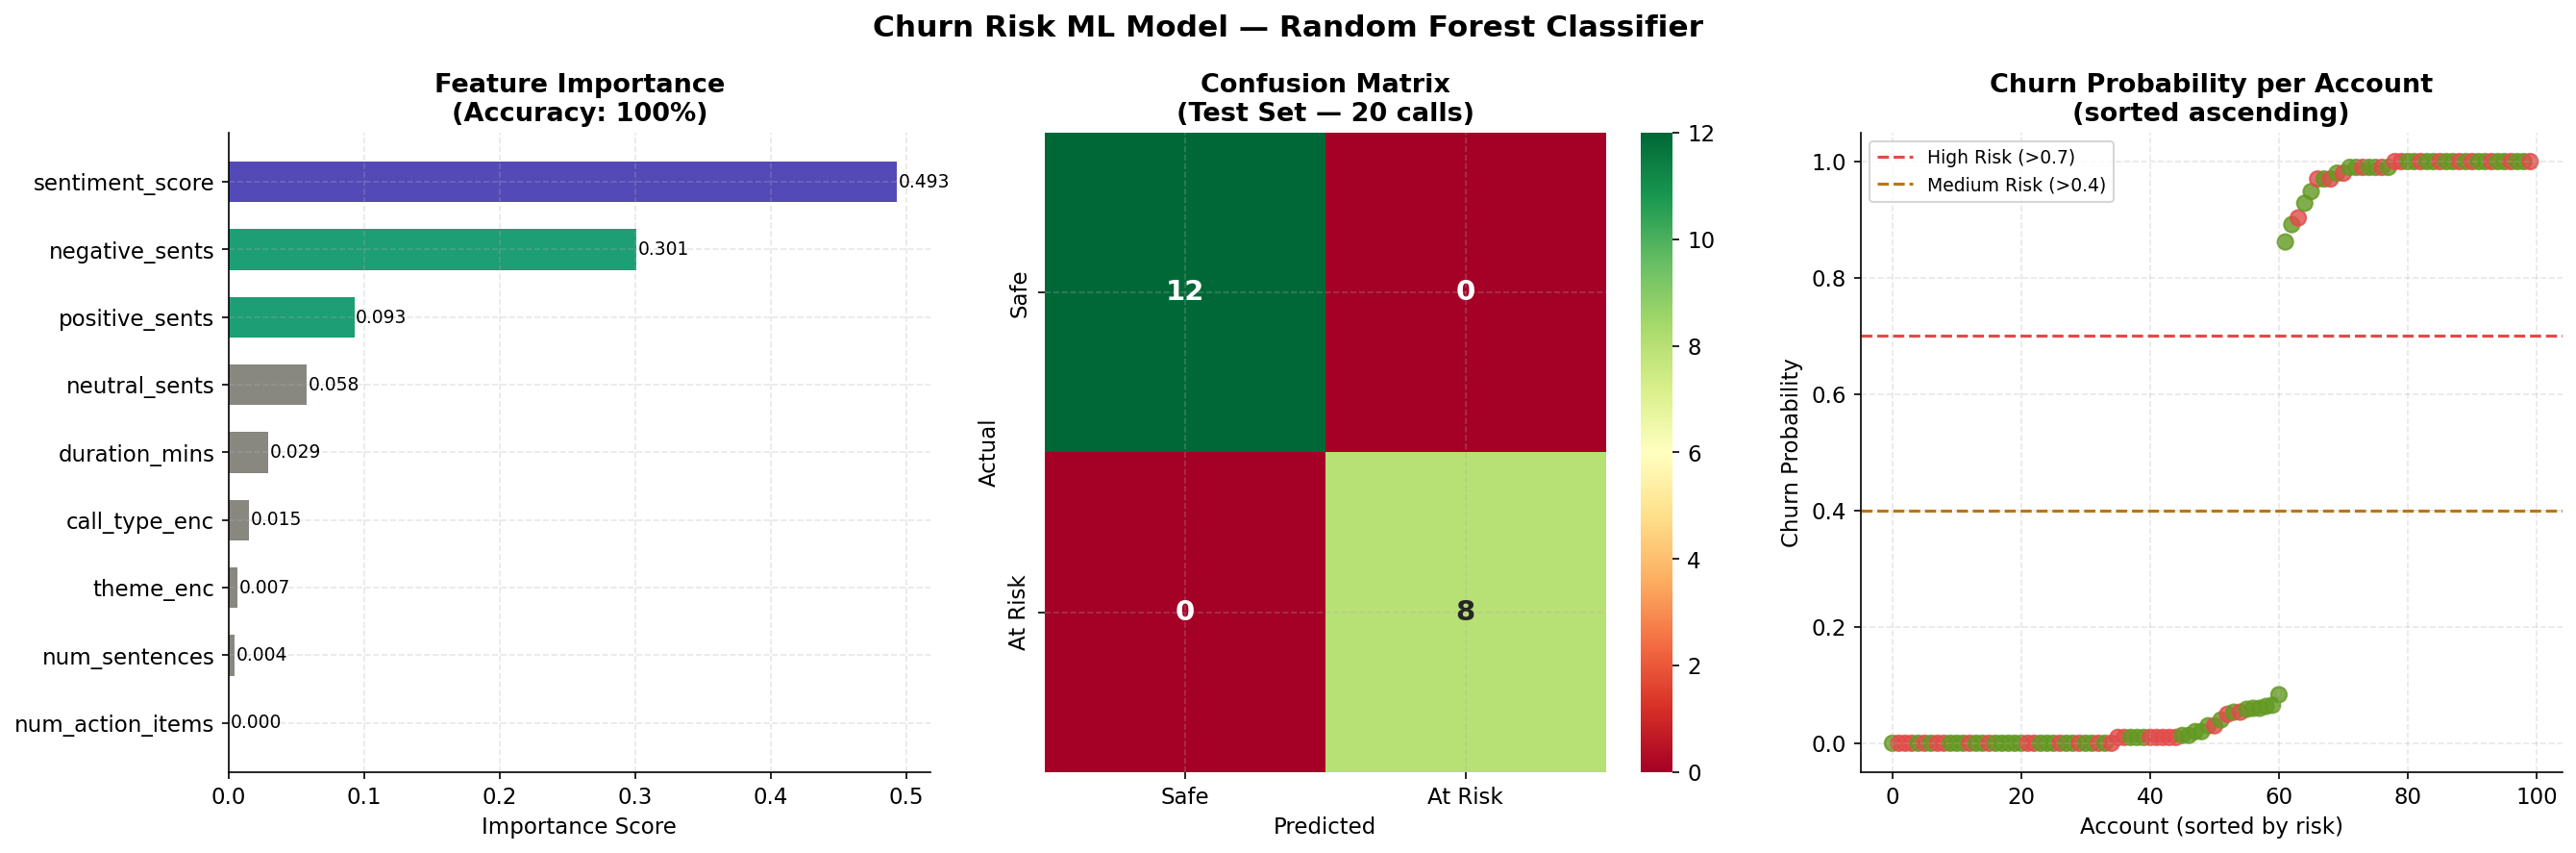

✅ Saved → 05_ml_model.png


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Rebuild model
le_type  = LabelEncoder()
le_theme = LabelEncoder()
df["call_type_enc"] = le_type.fit_transform(df["call_type"])
df["theme_enc"]     = le_theme.fit_transform(df["theme"])
df["churn_risk"]    = (
    (df["sentiment_score"] < 3.0) |
    (df["sentiment"].isin(["very-negative", "negative"]))
).astype(int)

features = ["sentiment_score", "num_action_items",
            "positive_sents", "negative_sents",
            "neutral_sents", "duration_mins",
            "num_sentences", "call_type_enc", "theme_enc"]

X = df[features]
y = df["churn_risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100,
                              max_depth=5, random_state=42)
rf.fit(X_train, y_train)
preds    = rf.predict(X_test)
acc      = (preds == y_test).mean()
feat_imp = pd.Series(rf.feature_importances_,
                     index=features).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Churn Risk ML Model — Random Forest Classifier",
             fontsize=15, fontweight="bold")

# Chart A — Feature importance
colors_fi = [PURPLE if v == feat_imp.max() else
             TEAL   if v >= feat_imp.quantile(0.7) else
             GRAY   for v in feat_imp.values]
axes[0].barh(feat_imp.index, feat_imp.values,
             color=colors_fi, height=0.6)
axes[0].set_title(f"Feature Importance\n(Accuracy: {acc*100:.0f}%)")
axes[0].set_xlabel("Importance Score")
for i, v in enumerate(feat_imp.values):
    axes[0].text(v + 0.001, i, f"{v:.3f}",
                 va="center", fontsize=9)

# Chart B — Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt="d",
            cmap="RdYlGn", ax=axes[1],
            xticklabels=["Safe", "At Risk"],
            yticklabels=["Safe", "At Risk"],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("Confusion Matrix\n(Test Set — 20 calls)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Chart C — Churn probability distribution
df["churn_prob"] = rf.predict_proba(X)[:, 1]
colors_prob = [RED   if p >= 0.7 else
               AMBER if p >= 0.4 else
               GREEN for p in df["churn_prob"]]
axes[2].scatter(range(len(df)),
                df.sort_values("churn_prob")["churn_prob"],
                c=colors_prob, s=60, alpha=0.8)
axes[2].axhline(0.7, color=RED, linestyle="--",
                linewidth=1.5, label="High Risk (>0.7)")
axes[2].axhline(0.4, color=AMBER, linestyle="--",
                linewidth=1.5, label="Medium Risk (>0.4)")
axes[2].set_title("Churn Probability per Account\n"
                   "(sorted ascending)")
axes[2].set_xlabel("Account (sorted by risk)")
axes[2].set_ylabel("Churn Probability")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHARTS_PATH}05_ml_model.png",
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved → 05_ml_model.png")

In [10]:
import os

print("=" * 55)
print("📊 ALL CHARTS GENERATED FOR SLIDE DECK")
print("=" * 55)

charts = [
    ("01_executive_dashboard.png",  "Slide 1 — KPIs + overview"),
    ("02_theme_intelligence.png",   "Slide 2 — Topic categorization"),
    ("03_sentiment_deepdive.png",   "Slide 3 — Sentiment analysis"),
    ("04_bonus_insights.png",       "Slide 4 — Repeat issues + burden"),
    ("05_ml_model.png",             "Slide 5 — ML churn predictor"),
]

for filename, slide in charts:
    path   = os.path.join(CHARTS_PATH, filename)
    exists = "✅" if os.path.exists(path) else "❌"
    size   = f"{os.path.getsize(path)/1024:.0f}KB" \
             if os.path.exists(path) else "missing"
    print(f"   {exists} {filename:<40} → {slide}  [{size}]")

print(f"\n📁 All charts saved to:")
print(f"   {CHARTS_PATH}")
print(f"\n🚀 Ready to build slide deck!")

📊 ALL CHARTS GENERATED FOR SLIDE DECK
   ✅ 01_executive_dashboard.png               → Slide 1 — KPIs + overview  [147KB]
   ✅ 02_theme_intelligence.png                → Slide 2 — Topic categorization  [192KB]
   ✅ 03_sentiment_deepdive.png                → Slide 3 — Sentiment analysis  [298KB]
   ✅ 04_bonus_insights.png                    → Slide 4 — Repeat issues + burden  [197KB]
   ✅ 05_ml_model.png                          → Slide 5 — ML churn predictor  [178KB]

📁 All charts saved to:
   /Users/ashishjain/Documents/assignment/transcript-intelligence/outputs/charts/

🚀 Ready to build slide deck!
